In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive/', force_remount=True)
# change path if necessary
os.chdir("/content/drive/MyDrive/TD_FIDS/")
os.getcwd()

Mounted at /content/drive/


'/content/drive/MyDrive/voiture'

### Charger l'image du papillon

Veuillez remplacer `votre_image_papillon.jpg` par le nom de votre fichier image qui se trouve dans le répertoire `/content/drive/MyDrive/voiture/`.

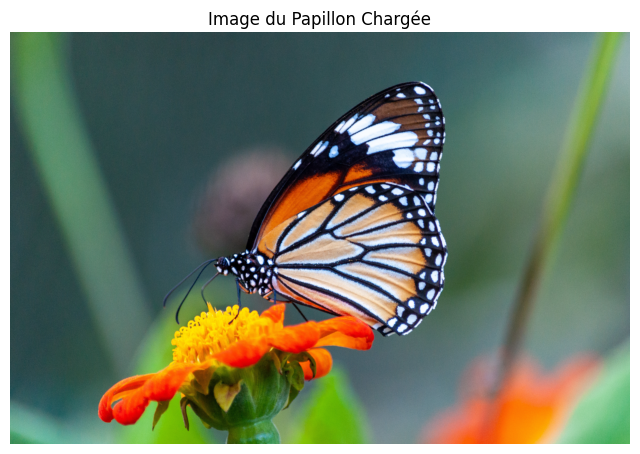

In [ ]:
import cv2
import matplotlib.pyplot as plt

# --- Spécifiez le chemin de votre image ici ---
# Exemple: 'mon_papillon.jpg' si l'image est dans '/content/drive/MyDrive/voiture/'
image_path_butterfly = 'butterfly.jpg' # Remplacez ceci par le nom de votre fichier image

# Charger l'image
butterfly_image = cv2.imread(image_path_butterfly)

if butterfly_image is None:
    print(f"Erreur: Impossible de charger l'image depuis {image_path_butterfly}. Veuillez vérifier le nom du fichier et son emplacement.")
else:
    # Convertir de BGR (OpenCV) à RGB (Matplotlib)
    butterfly_image_rgb = cv2.cvtColor(butterfly_image, cv2.COLOR_BGR2RGB)

    # Afficher l'image pour vérifier
    plt.figure(figsize=(8, 6))
    plt.imshow(butterfly_image_rgb)
    plt.title('Image du Papillon Chargée')
    plt.axis('off')
    plt.show()

### Détection de Contours avec l'algorithme de Canny

L'algorithme de Canny est un détecteur de contours très efficace. Il commence par lisser l'image avec un filtre gaussien (une forme de convolution) pour réduire le bruit, puis il calcule les gradients d'intensité de l'image (également via convolution avec des filtres comme Sobel), effectue une suppression non-maximale et applique un seuillage par hystérésis pour obtenir des contours finaux.

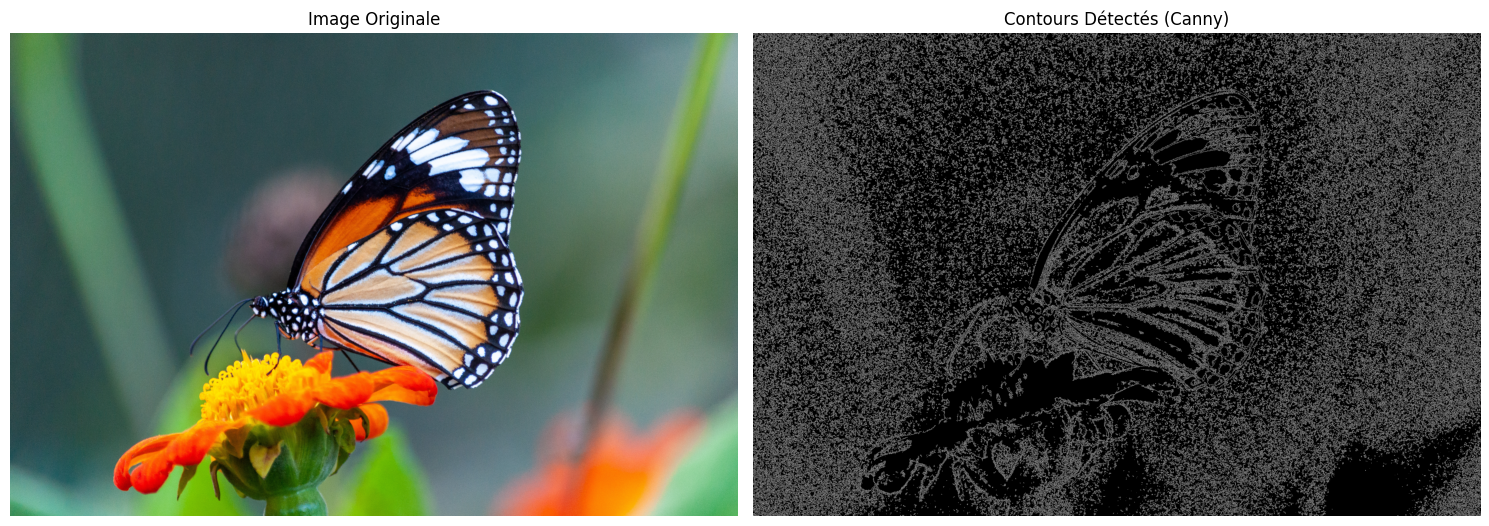

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Assurez-vous que butterfly_image a bien été chargée
if butterfly_image is None:
    print("L'image du papillon n'est pas chargée. Veuillez exécuter la cellule précédente.")
else:
    # 1. Convertir l'image en niveaux de gris (Canny fonctionne mieux sur les images en niveaux de gris)
    gray_image = cv2.cvtColor(butterfly_image, cv2.COLOR_BGR2GRAY)

    # 2. Appliquer la détection de contours de Canny
    # Les deux derniers arguments sont les seuils min et max pour l'hystérésis.
    # Vous pouvez ajuster ces valeurs pour obtenir des résultats différents.
    # Un seuil bas de 50 et un seuil haut de 150 sont de bonnes valeurs de départ.
    edges = cv2.Canny(gray_image, 50, 150)

    # Afficher l'image originale et les contours détectés
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    axes[0].imshow(butterfly_image_rgb) # Utilisez l'image RGB pour l'original
    axes[0].set_title('Image Originale')
    axes[0].axis('off')

    axes[1].imshow(edges, cmap='gray')
    axes[1].set_title('Contours Détectés (Canny)')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

### Création du fichier `requirements.txt`

Ce fichier liste les dépendances de votre projet Python, avec leurs versions spécifiques, ce qui garantit que l'environnement peut être recréé de manière identique sur n'importe quelle machine.

In [ ]:
import subprocess
import sys

# Liste des packages que nous souhaitons inclure
packages_to_include = [
    'ultralytics',
    'opencv-python',
    'matplotlib',
    'numpy'
]

# Assurez-vous que ultralytics est installé pour être capturé par pip freeze
print("Vérification et installation de 'ultralytics'...")
try:
    subprocess.run(['pip', 'install', 'ultralytics'], capture_output=True, text=True, check=True)
    print("'ultralytics' est installé ou déjà à jour.")
except subprocess.CalledProcessError as e:
    print(f"Erreur lors de l'installation de 'ultralytics': {e}")
    # Gérer l'erreur si l'installation échoue, mais continuer pour le reste si possible

# Exécuter 'pip freeze' pour obtenir tous les packages installés avec leurs versions
try:
    result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True, check=True)
    installed_packages_output = result.stdout.splitlines()
except subprocess.CalledProcessError as e:
    print(f"Erreur lors de l'exécution de 'pip freeze': {e}")
    installed_packages_output = []

requirements = []
for line in installed_packages_output:
    # Extraire le nom du package (avant le '==' ou autre séparateur)
    pkg_name = line.split('==')[0].split('<')[0].split('>')[0].split('~')[0].strip()

    # Vérifier si le package est dans notre liste d'intérêt (insensible à la casse)
    # Et gérer les noms différents comme opencv-python vs cv2
    if pkg_name.lower() in [p.lower() for p in packages_to_include] or \
       ('opencv-python' in [p.lower() for p in packages_to_include] and pkg_name.lower() == 'opencv-python'):
        requirements.append(line)

# Ajouter la version de Python
python_version = f"# Python {sys.version.split(' ')[0]}"

# Écrire les dépendances dans requirements.txt
requirements_path = 'requirements.txt'
with open(requirements_path, 'w') as f:
    f.write(f"{python_version}\n") # Écrire la version de Python en premier
    for req in requirements:
        f.write(f"{req}\n")

print(f"Le fichier '{requirements_path}' a été créé avec succès. Contenu :\n")
with open(requirements_path, 'r') as f:
    print(f.read())

Vérification et installation de 'ultralytics'...
'ultralytics' est installé ou déjà à jour.
Le fichier 'requirements.txt' a été créé avec succès. Contenu :

# Python 3.12.13
matplotlib==3.10.0
numpy==2.0.2
opencv-python==5.0.0.93
ultralytics==8.4.107

